In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

# ===============================
# Handle existing 'features' column for re-runs
# ===============================

if "features" in df.columns:
    df = df.drop("features")

# ===============================
#  Define Columns
# ===============================

numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "Credit_Score",
    "Employment_Years",
    "Credit_History",
    "Has_Defaulted",
    "Dependents"
]

categorical_encoded_cols = [
    "Gender_encoded",
    "Education_Level_encoded",
    "Married_encoded",
    "Job_Type_encoded",
    "Property_Area_encoded"
]

# ===============================
#  Assemble Final Features Only
# ===============================

assembler = VectorAssembler(
    inputCols=numeric_cols + categorical_encoded_cols,
    outputCol="features",
    handleInvalid="keep"
)

# ===============================
#  Build Pipeline
# ===============================

pipeline = Pipeline(stages=[assembler])

pipeline_model = pipeline.fit(df)

df_final = pipeline_model.transform(df)


print("Total Rows:", df_final.count())
df_final = df_final.withColumnRenamed("Loan_Status", "label")
print("Renamed 'Loan_Status' to 'label'.")

Pipeline Built Successfully (No Preprocessing)
Total Rows: 1008883
Renamed 'Loan_Status' to 'label'.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ===============================
#  Train/Test Split
# ===============================

train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print("Train Count:", train_data.count())
print("Test Count:", test_data.count())

Train Count: 806937
Test Count: 201946


In [ ]:
# ===============================
# Logistic Regression Definition
# ===============================

from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

print("Logistic Regression Model Initialized")

Logistic Regression Model Initialized


In [ ]:
# ===============================
# Training
# ===============================

model = lr.fit(train_data)

print("Training Complete")

Training Complete


In [ ]:
# ===============================
#Prediction
# ===============================

predictions = model.transform(test_data)

print("Prediction Complete")

predictions.select("label", "prediction", "probability").show(10)

Prediction Complete
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.98199410463969...|
|    0|       0.0|[0.94410654612391...|
|    0|       0.0|[0.99326806575271...|
|    0|       0.0|[0.98816609044958...|
|    0|       0.0|[0.97313900327485...|
|    0|       0.0|[0.99227759233687...|
|    0|       0.0|[0.94872248266973...|
|    0|       0.0|[0.91153853103393...|
|    0|       0.0|[0.99487387785740...|
|    0|       0.0|[0.97503754940543...|
+-----+----------+--------------------+
only showing top 10 rows


In [ ]:
# ===============================
# Accuracy
# ===============================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8108355699048261


In [ ]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1 = f1_evaluator.evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.8089312455236428


In [ ]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

precision = precision_evaluator.evaluate(predictions)

print("Precision:", precision)

Precision: 0.8096365899715663


In [ ]:
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

recall = recall_evaluator.evaluate(predictions)

print("Recall:", recall)

Recall: 0.810835569904826


In [ ]:
# ===============================
# AUC
# ===============================

from pyspark.ml.evaluation import BinaryClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = auc_evaluator.evaluate(predictions)

print("AUC:", auc)

AUC: 0.8873932393102301


In [ ]:
print("====== FINAL EVALUATION ======")
print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("Precision:", precision)
print("Recall   :", recall)
print("AUC      :", auc)

====== FINAL EVALUATION ======
Accuracy : 0.8108355699048261
F1 Score : 0.8089312455236428
Precision: 0.8096365899715663
Recall   : 0.810835569904826
AUC      : 0.8873932393102301


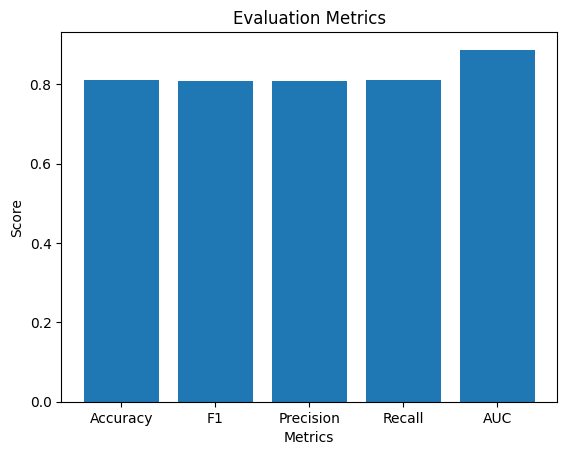

In [ ]:
# ===============================
#  Evaluation Visualization
# ===============================

import matplotlib.pyplot as plt

metrics = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
scores = [accuracy, f1, precision, recall, auc]

plt.figure()
plt.bar(metrics, scores)
plt.title("Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

In [ ]:
# ===============================
#  Confusion Matrix
# ===============================

conf_matrix = predictions.groupBy("label", "prediction").count()
conf_matrix.show()

+-----+----------+------+
|label|prediction| count|
+-----+----------+------+
|    1|       0.0| 15151|
|    0|       0.0| 57410|
|    1|       1.0|106335|
|    0|       1.0| 23050|
+-----+----------+------+



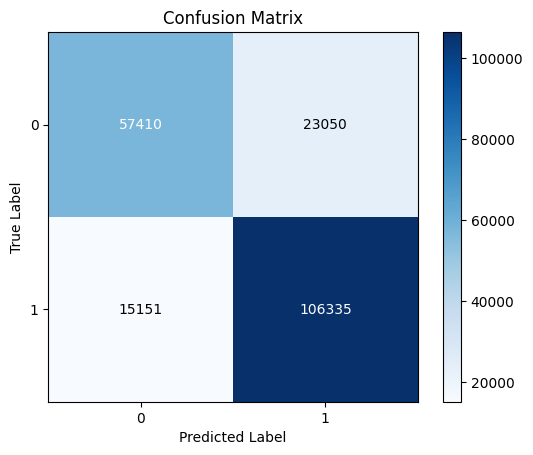

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Extract true labels and predictions from the Spark DataFrame
y_true = predictions.select("label").toPandas().squeeze()
y_pred = predictions.select("prediction").toPandas().squeeze()

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

# Get unique classes from true labels
classes = np.unique(y_true)

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black") # Adjust text color for contrast

plt.show()

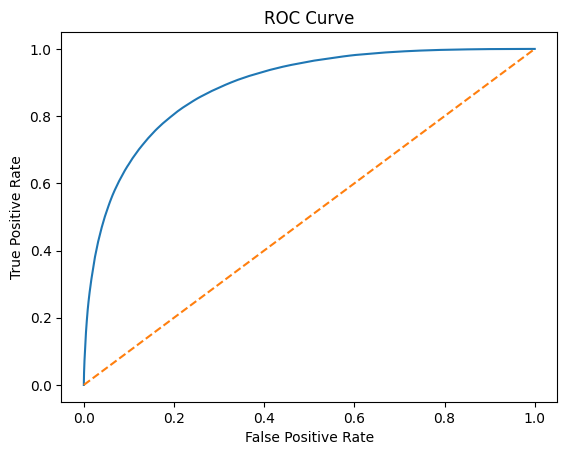

In [ ]:
#  ROC Curve
# ===============================

training_summary = model.summary
roc = training_summary.roc.toPandas()

plt.figure()
plt.plot(roc['FPR'], roc['TPR'])
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

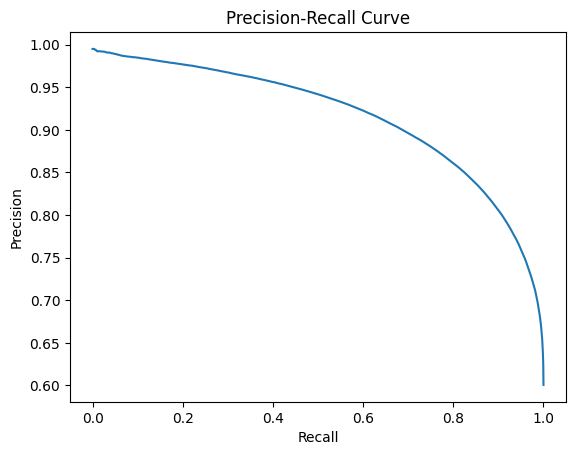

In [ ]:
pr = training_summary.pr.toPandas()

plt.figure()
plt.plot(pr['recall'], pr['precision'])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
#  Feature Importance
# ===============================

import pandas as pd
from pyspark.ml.feature import StringIndexerModel, OneHotEncoderModel

coefficients = model.coefficients.toArray()

# --- Reconstruct feature names from pipeline metadata ---
feature_names_from_assembler = []

# Access the metadata of the 'features' column in df_final
# This metadata contains the actual names of the features that make up the vector
feature_metadata_attrs = df_final.schema['features'].metadata['ml_attr']['attrs']

# Iterate through different types of attributes (numeric, binary, nominal) that contribute to the vector
# The order here should match how VectorAssembler combines them implicitly
for attr_type in ['numeric', 'binary', 'nominal']:
    if attr_type in feature_metadata_attrs:
        for attr in feature_metadata_attrs[attr_type]:
            feature_names_from_assembler.append(attr['name'])

# Use the extracted names, or fallback to generic ones if something goes wrong
if len(feature_names_from_assembler) != len(coefficients):
    print(f"DEBUG: Mismatch in feature names length ({len(feature_names_from_assembler)}) and coefficients length ({len(coefficients)}).")
    # Fallback to generic names if metadata extraction is problematic
    all_features_for_importance = [f"feature_{i}" for i in range(len(coefficients))]
else:
    all_features_for_importance = feature_names_from_assembler

feature_importance = pd.DataFrame({
    "Feature": all_features_for_importance,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance)

                    Feature  Coefficient
5            Credit_History     2.022462
4          Employment_Years     0.051469
9   Education_Level_encoded     0.035442
3              Credit_Score     0.008654
0                       Age     0.000693
1                    Income     0.000028
2                LoanAmount    -0.000006
7                Dependents    -0.139962
8            Gender_encoded    -0.147438
12    Property_Area_encoded    -0.172120
11         Job_Type_encoded    -0.322979
10          Married_encoded    -0.444932
6             Has_Defaulted    -1.564847


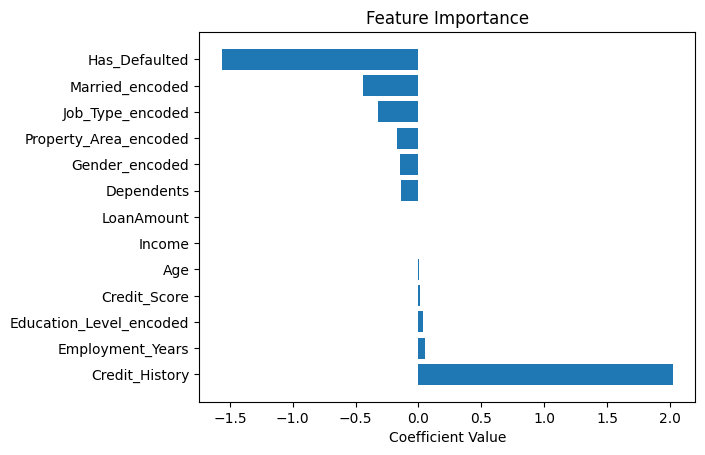

In [ ]:
plt.figure()
plt.barh(feature_importance["Feature"], feature_importance["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
# ===============================
#  Save Model
# ===============================

model.save("spark_logistic_model")

print("Model Saved Successfully")

Model Saved Successfully
